Week 9 (23/04/2025) - Unsupervised learning

Unsupervised learning deals with unlabelled data points, meaning that an unsupervised learning model generally aims to find patterns/regularities in data via clustering.

Generally speaking, clustering is an unsupervised learning algorithm that, given a training set and k centroids, tries to map each data point to the corresponding centroid and cluster.

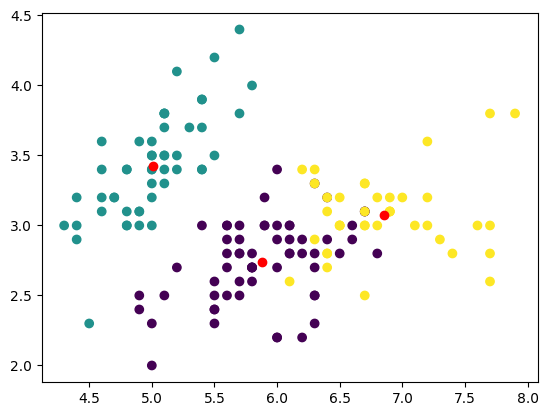

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Start by loading the iris data set.
iris = sns.load_dataset("iris")
X_iris = iris.drop("species", axis=1) # take away the categorical label
y_iris = iris["species"] # take the labels, which are not needed as unsupervised learning uses unlabelled points

# Create an instance of the K-means algorithm for clustering.
model = KMeans(n_clusters=3) # instance with 3 clusters

# Train the model using the training dataset.
model.fit(X_iris) # in this case, it is not necessary to split the data as classification does not use the dataset labels
y_predict = model.predict(X_iris) # this allows to determine the cluster number of each data point

# Plot the dataset to check whether the dataset has been correctly clustered.
plt.scatter(X_iris["sepal_length"], X_iris["sepal_width"], c=y_predict) # plot sepal length vs sepal width and distinguish the points by their cluster
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], c="red") # plot the centroids
plt.show()

The main application of clustering consists in colour reduction for images.

In [ ]:
import numpy as np
import cv2
from sklearn.cluster import KMeans

# Start by loading the image and convert it into a 2D matrix for Scikit-Learn compatibility.
# Scikit-Learn avrebbe un attimino rotto i maroni (NdA)
img_arr = cv2.imread("01-Data/lena.png")
(h, w, c) = img_arr.shape # before the conversion, save the dimensions of the image to recreate the output image
img2D = img_arr.reshape(h*w, c) # turn the image in a 2D table of size h*w x c (pixel by colour)

# Create an instance of the K-means algorithm for clustering.
kmeans_model = KMeans(n_clusters=8) # instance with 8 clusters
cluster_label = kmeans_model.fit_predict(img2D) # perform the fitting and the prediction for each pixel
rgb_cols = kmeans_model.cluster_centers_.round(0).astype(int) # round down the coordinates and convert to int

# At this point, it is possible to reconstruct the image
img_quant = np.reshape(rgb_cols[cluster_label], (h, w, c)) # convert the cluster colors to the original image shape
img_quant = img_quant.astype("uint8") # make sure that the values are converted to unsigned 8-bit integers

cv2.imshow("Reconstructed Image", img_quant)
cv2.waitKey(0)
cv2.closeAllWindows()

Generally speaking, natural language processing deals with interactions between computers and the human language in order to process and analyze large amount of natural language data. <br>
Nowadays, most NLP models fall within the "Neural NLP" category, which works using neural methods such as deep neural networks. <br>
Overall, NLP is hard due to the following issues:
- **Ambiguity**: The text may be ambiguous at word/speech/syntax/meaning/language level.
- **Scale**: Choose the languages the model should consider.
- **Sparsity**: Proportions of words within the text (this also allows to spot eventual important words).
- **Variation**: NLP context.
- **Expressivity**: The same sentence can be worded in different ways, all with the same meaning.
Luckily, NLP managed to improve thanks to improvement in computing, web tools and machine learning models.

In [6]:
import nltk

nltk.download('omw-1.4')
nltk.download('tagsets')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/gianmaria/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package tagsets to
[nltk_data]     /home/gianmaria/nltk_data...
[nltk_data]   Package tagsets is already up-to-date!
[nltk_data] Downloading package punkt to /home/gianmaria/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/gianmaria/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/gianmaria/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/gianmaria/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/gianmaria/nltk_data...
[nltk_data]   Unzipping

True

In [7]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Tokenizing a text consists in dividing it into smaller parts known as "tokens" (typically words or sentences).
example_string = "All the speed he took, all the turns he'd taken"
s_tokenized = sent_tokenize(example_string) # split into smaller sentences
print(s_tokenized)
w_tokenized = word_tokenize(example_string) # split into words
print(w_tokenized)

# A "stopword" is a word that does not provide any useful insight for processing the text.
example_string = "It's leviosa, not leviosaaaa" # fuck JKR btw (NdA)
words = word_tokenize(example_string) # get the words
stop_words = set(stopwords.words("english")) # set the language of the text in order to correctly spot the stopwords
filtered_list = []
# At this point, remove the stopwords by iterating through the tokenized words.
for word in words:
    if word.casefold() not in stop_words: # use casefold to ignore case sensitivity
        filtered_list.append(word)
print(filtered_list)

# Stemming consists in reducing a word to its root.
# Start by creating an instance of the stemming model.
stemmer = PorterStemmer()
words = "The crew of the USS Discovery discovered many discoveries. Discovering is what explorers do"
stemmed_words = [stemmer.stem(word) for word in words] # list comprehension performing the stemming task
print(stemmed_words)

["All the speed he took, all the turns he'd taken"]
['All', 'the', 'speed', 'he', 'took', ',', 'all', 'the', 'turns', 'he', "'d", 'taken']
["'s", 'leviosa', ',', 'leviosaaaa']
['t', 'h', 'e', ' ', 'c', 'r', 'e', 'w', ' ', 'o', 'f', ' ', 't', 'h', 'e', ' ', 'u', 's', 's', ' ', 'd', 'i', 's', 'c', 'o', 'v', 'e', 'r', 'y', ' ', 'd', 'i', 's', 'c', 'o', 'v', 'e', 'r', 'e', 'd', ' ', 'm', 'a', 'n', 'y', ' ', 'd', 'i', 's', 'c', 'o', 'v', 'e', 'r', 'i', 'e', 's', '.', ' ', 'd', 'i', 's', 'c', 'o', 'v', 'e', 'r', 'i', 'n', 'g', ' ', 'i', 's', ' ', 'w', 'h', 'a', 't', ' ', 'e', 'x', 'p', 'l', 'o', 'r', 'e', 'r', 's', ' ', 'd', 'o']
